# Conditional WGAN-GP Spectrogram Generator

Extra / future work: this notebook is a report-first companion for the
historical WGAN-GP generator. It produces normalized 128 x 128 log-mel
spectrograms and is intentionally separate from the current CRNN augmentation
evaluation.


## Goal

1. Inspect the class-conditional generator and critic contract.
2. Visualize the recorded 20-epoch run and detail-ratio evidence.
3. Play the three curated Griffin-Lim examples.
4. Keep retraining, generation, and classifier evaluation explicitly opt-in.


## 1. Setup


In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Audio, display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
SOURCE_ROOT = PROJECT_ROOT / "src"
if str(SOURCE_ROOT) not in sys.path:
    sys.path.insert(0, str(SOURCE_ROOT))

from bird_song.generation.wgan_gp import (
    ConditionalCritic,
    ConditionalGenerator,
    WGANConfig,
    count_parameters,
)
from bird_song.runtime import seed_everything

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

REPORT_DIR = PROJECT_ROOT / "reports" / "generator_baselines" / "wgan_gp"
CACHE_MANIFEST = PROJECT_ROOT / "artifacts" / "spectrograms" / "spectrogram_manifest.csv"
CACHE_ROOT = PROJECT_ROOT / "artifacts" / "spectrograms"
MODEL_CONFIG = PROJECT_ROOT / "configs" / "wgan_gp.json"
RUN_DIR = PROJECT_ROOT / "runs" / "wgan_gp_notebook"
CHECKPOINT_PATH = RUN_DIR / "best.pt"
GENERATED_DIR = PROJECT_ROOT / "outputs" / "wgan_gp_notebook"
LOCAL_RECORDED_OUTPUT = PROJECT_ROOT / "outputs" / "wgan_gp_real"
CLASSIFIER_CHECKPOINT = PROJECT_ROOT / "artifacts" / "models" / "classifier" / "selected_crnn" / "best.pt"

RUN_TRAINING = False
RUN_GENERATION = False
RUN_CLASSIFIER_EVALUATION = False
OVERWRITE_OUTPUTS = False
SEED = 42

seed_everything(SEED)
model_config = WGANConfig.from_dict(json.loads(MODEL_CONFIG.read_text(encoding="utf-8")))
print("Project root:", PROJECT_ROOT)
print("Device:", DEVICE)
print("WGAN configuration:", model_config)


Project root: C:\Users\Harvey\Documents\Coding\bird_song_gen
Device: cuda
WGAN configuration: WGANConfig(image_size=128, channels=1, num_classes=3, latent_dim=128, base_channels=64, label_dim=64, critic_base_channels=64, gradient_penalty_weight=10.0, critic_steps=5)


## 2. Architecture and shape contract


In [2]:
generator = ConditionalGenerator(model_config).to(DEVICE)
critic = ConditionalCritic(model_config).to(DEVICE)
labels = torch.arange(model_config.num_classes, device=DEVICE, dtype=torch.long)
noise = torch.randn(model_config.num_classes, model_config.latent_dim, device=DEVICE)
with torch.inference_mode():
    fake_images = generator(noise, labels)
    critic_scores = critic(fake_images, labels)
print("Generator parameters:", f"{count_parameters(generator):,}")
print("Critic parameters:", f"{count_parameters(critic):,}")
print("Generated shape:", tuple(fake_images.shape))
print("Critic score shape:", tuple(critic_scores.shape))
del generator, critic, fake_images, critic_scores


Generator parameters: 12,599,009
Critic parameters: 23,753,025
Generated shape: (3, 1, 128, 128)
Critic score shape: (3,)


## 3. Recorded training dynamics

The selected historical checkpoint was chosen by the highest mean detail ratio
at epoch 18. Detail sharpness can also reflect noise, so this is a selection
heuristic rather than a realism metric.


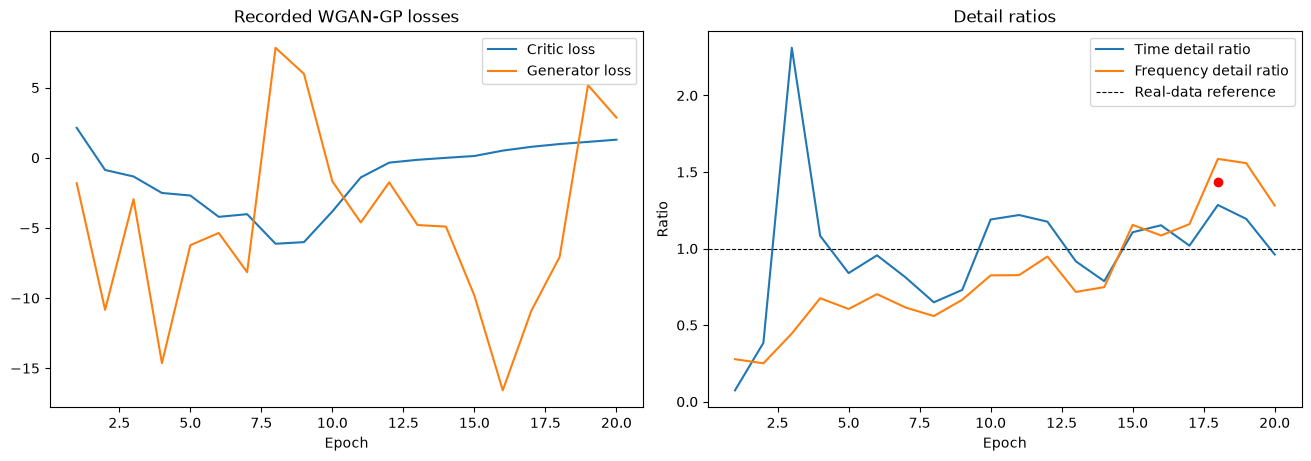

,epoch,critic_loss,generator_loss,gradient_penalty,validation_gap,time_detail_ratio,frequency_detail_ratio,seconds
15,16,0.511756,-16.579158,0.036971,-0.089147,1.152141,1.085536,14.601788
16,17,0.780771,-10.926928,0.044378,-0.652184,1.018996,1.159858,14.412752
17,18,0.981414,-7.070781,0.042287,0.943410,1.284600,1.585667,14.034461
18,19,1.134860,5.179007,0.043681,-0.774603,1.193599,1.558005,13.704959
19,20,1.289703,2.869332,0.051638,-0.749042,0.961620,1.281466,13.505707


Recorded selection epoch: 18


In [3]:
history_path = REPORT_DIR / "wgan_gp_history.csv"
history = pd.read_csv(history_path)
best_index = ((history["time_detail_ratio"] + history["frequency_detail_ratio"]) / 2).idxmax()
best_row = history.loc[best_index]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
axes[0].plot(history["epoch"], history["critic_loss"], label="Critic loss")
axes[0].plot(history["epoch"], history["generator_loss"], label="Generator loss")
axes[0].set(xlabel="Epoch", title="Recorded WGAN-GP losses")
axes[0].legend()
axes[1].plot(history["epoch"], history["time_detail_ratio"], label="Time detail ratio")
axes[1].plot(history["epoch"], history["frequency_detail_ratio"], label="Frequency detail ratio")
axes[1].axhline(1.0, color="black", linestyle="--", linewidth=0.8, label="Real-data reference")
axes[1].scatter(best_row["epoch"], (best_row["time_detail_ratio"] + best_row["frequency_detail_ratio"]) / 2, color="red", zorder=3)
axes[1].set(xlabel="Epoch", ylabel="Ratio", title="Detail ratios")
axes[1].legend()
plt.show()
display(history.tail())
print("Recorded selection epoch:", int(best_row["epoch"]))


## 4. Recorded quality evidence


In [4]:
summary = json.loads((REPORT_DIR / "summary.json").read_text(encoding="utf-8"))
wgan = summary["wgan_gp"]
quality_table = pd.DataFrame([
    {
        "metric": "Legacy residual target agreement",
        "value": wgan["residual_classifier_target_accuracy"],
    },
    {
        "metric": "Current CRNN target agreement",
        "value": wgan["crnn_target_accuracy"],
    },
])
display(quality_table.style.format({"value": "{:.2%}"}))
detail_rows = [
    {"species": species, **metrics}
    for species, metrics in wgan["per_species_detail_ratios"].items()
]
display(pd.DataFrame(detail_rows).style.format({
    "time": "{:.2f}",
    "frequency": "{:.2f}",
}))


,metric,value
0,Legacy residual target agreement,84.90%
1,Current CRNN target agreement,40.62%


,species,time,frequency
0,American Robin,1.67,1.67
1,Northern Cardinal,1.49,1.90
2,Song Sparrow,0.69,1.11


## 5. Curated audio

These are three-second Griffin-Lim demonstrations. Phase recovery is not
available from the discarded log-mel phase, so listening remains a necessary
quality check.


In [5]:
for audio_name in ("american_robin.wav", "northern_cardinal.wav", "song_sparrow.wav"):
    audio_path = REPORT_DIR / "audio" / audio_name
    if audio_path.is_file():
        print(audio_name)
        display(Audio(filename=str(audio_path)))
    else:
        print("Missing curated audio:", audio_path)


american_robin.wav


northern_cardinal.wav


song_sparrow.wav


## 6. Optional training and generation


In [6]:
def run_project_script(script_name, arguments):
    environment = os.environ.copy()
    existing_pythonpath = environment.get("PYTHONPATH")
    environment["PYTHONPATH"] = str(SOURCE_ROOT) + (
        os.pathsep + existing_pythonpath if existing_pythonpath else ""
    )
    command = [sys.executable, str(PROJECT_ROOT / "scripts" / script_name), *map(str, arguments)]
    print("Running:", " ".join(command))
    return subprocess.run(command, cwd=PROJECT_ROOT, env=environment, check=True)

if RUN_TRAINING:
    training_arguments = [
        "--cache-manifest", CACHE_MANIFEST,
        "--cache-root", CACHE_ROOT,
        "--model-config", MODEL_CONFIG,
        "--output-dir", RUN_DIR,
        "--epochs", 20,
        "--critic-steps", 2,
        "--batch-size", 32,
        "--workers", 0,
        "--device", DEVICE,
    ]
    if OVERWRITE_OUTPUTS:
        training_arguments.append("--overwrite")
    run_project_script("08_train_wgan_gp.py", training_arguments)
else:
    print("Training disabled. Set RUN_TRAINING = True for future WGAN-GP work.")


Training disabled. Set RUN_TRAINING = True for future WGAN-GP work.


In [7]:
if RUN_GENERATION:
    if not CHECKPOINT_PATH.is_file():
        raise FileNotFoundError(f"Local WGAN-GP checkpoint is required for generation: {CHECKPOINT_PATH}")
    generation_arguments = [
        "--checkpoint", CHECKPOINT_PATH,
        "--output-dir", GENERATED_DIR,
        "--samples-per-species", 8,
        "--seed", SEED,
        "--device", DEVICE,
    ]
    if OVERWRITE_OUTPUTS:
        generation_arguments.append("--overwrite")
    run_project_script("08_generate_wgan_gp.py", generation_arguments)
else:
    print("Generation disabled. Set RUN_GENERATION = True after a local checkpoint exists.")


Generation disabled. Set RUN_GENERATION = True after a local checkpoint exists.


## 7. Optional generated grid and classifier check


,available_samples
species,
American Robin,64
Northern Cardinal,64
Song Sparrow,64


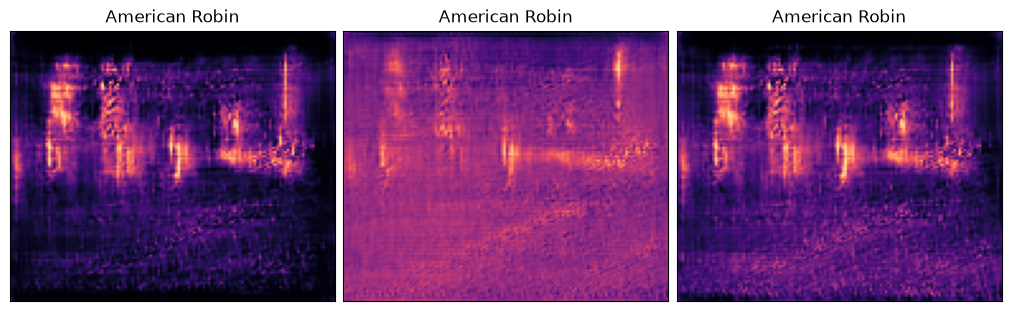

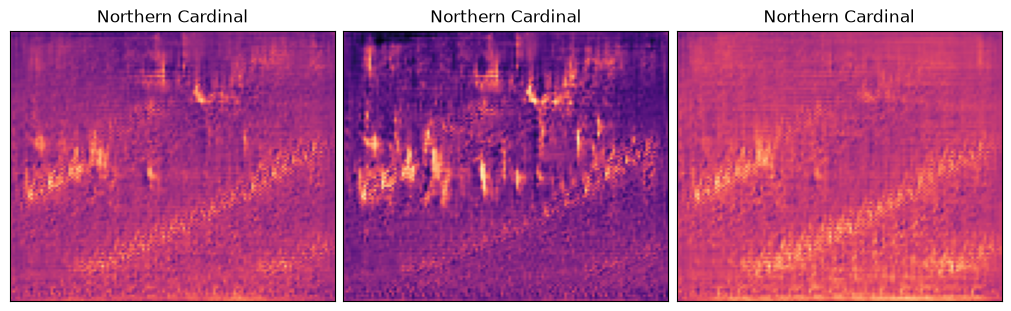

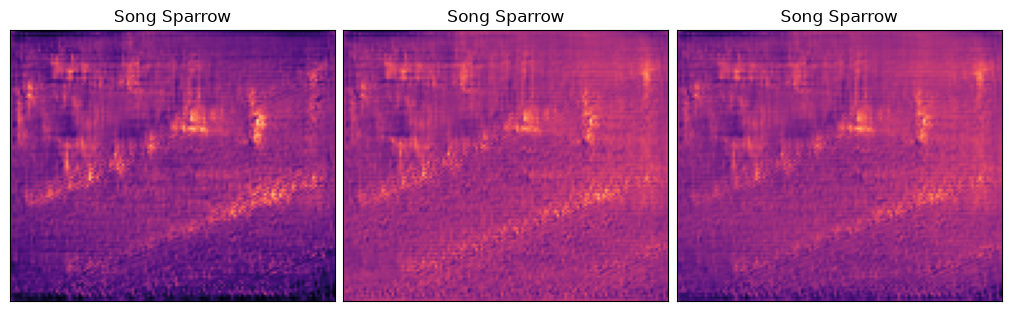

In [8]:
generated_manifest_path = GENERATED_DIR / "generated_manifest.csv"
if not generated_manifest_path.is_file() and LOCAL_RECORDED_OUTPUT.joinpath("generated_manifest.csv").is_file():
    generated_root = LOCAL_RECORDED_OUTPUT
    generated_manifest_path = generated_root / "generated_manifest.csv"
else:
    generated_root = GENERATED_DIR

if generated_manifest_path.is_file():
    candidate = pd.read_csv(generated_manifest_path)
    available = candidate[candidate["relative_path"].map(lambda value: (generated_root / value).is_file())]
    if available.empty:
        print("A generated manifest exists but no arrays are available.")
    else:
        display(available.groupby("species").size().rename("available_samples").to_frame())
        for species in available["species"].unique():
            species_rows = available[available["species"] == species].head(3)
            fig, axes = plt.subplots(1, len(species_rows), figsize=(10, 3), squeeze=False, constrained_layout=True)
            for axis, row in zip(axes.flat, species_rows.itertuples(index=False)):
                image = np.load(generated_root / row.relative_path, allow_pickle=False)
                axis.imshow(image, origin="lower", aspect="auto", cmap="magma", vmin=-1, vmax=1)
                axis.set_title(species)
                axis.set_xticks([])
                axis.set_yticks([])
            plt.show()
else:
    print("No local generated manifest is available; report mode does not require one.")


In [9]:
if RUN_CLASSIFIER_EVALUATION:
    if not generated_root.is_dir() or not CLASSIFIER_CHECKPOINT.is_file():
        raise FileNotFoundError("Generated output and the selected CRNN checkpoint are required.")
    run_project_script("07_evaluate_generated.py", [
        "--checkpoint", CLASSIFIER_CHECKPOINT,
        "--input", generated_root,
        "--output", generated_root / "classifier_scores.csv",
        "--labels-from-parent",
        "--device", DEVICE,
        "--workers", 0,
    ])
else:
    print("Classifier evaluation disabled.")


Classifier evaluation disabled.


## Takeaways

The historical WGAN-GP run is a useful sharp-spectrogram baseline, not an
audio-ready model. The legacy residual classifier matched requested labels on
84.90% of generated samples, while the independent CRNN matched only 40.63%.
Detail ratios also overshot real-data energy for Robin and Cardinal, which may
represent sharp structure, noise, or both.

Future WGAN work should use multiple seeds and select checkpoints using detail
closeness, diversity, and cross-classifier consistency instead of maximum
sharpness alone.
